#***Flujo del proyecto***
1. Comprensión del negocio
2. Análisis exploratorio de los datos (EDA)
3. Preprocesamiento: Limpieza, calidad e ingeniería de carácteristicas
4. Entrenamiento de los modelos: Cuantos? Cuáles? --> Depende de las métricas
5. Evaluación: Comparar métricas
6. Modelo final y conclusiones

## **1. Comprensión del negocio**



### **A. Contexto del Problema**
La accidentalidad vial en Colombia, y específicamente en departamentos con alta densidad vehicular como Antioquia, representa un problema crítico de salud pública y de gestión de recursos estatales. Sin embargo, en este ámbito, la calidad de la información recopilada por los agentes de tránsito suele ser inconsistente, presentando valores nulos, errores de digitación y formatos incorrectos. Por lo tanto, antes de poder generar cualquier modelo de inteligencia artificial sobre estos datos, es un requisito técnico indispensable aplicar procesos de Data Cleaning para garantizar la calidad y confiabilidad de la información.



### **B. Formulación de Preguntas de Negocio**

**Pregunta Descriptiva**
- Cuáles son los patrones de accidentalidad más recurrentes en Antioquia según la clase de accidente (choque, volcamiento) y la hora del día, variables que presentan la mayor confiabilidad en el dataset?


**Pregunta Predictiva (Enfoque en Machine Learning)**
- ¿Qué nivel de precisión podemos alcanzar al predecir la gravedad de un siniestro vial utilizando algoritmos de clasificación?

## **2.Análisis exploratorio de los datos (EDA)**

### **A. Importación de las librerías**

In [1]:
!pip install adjustText

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from adjustText import adjust_text
from google.colab import drive
from sklearn import preprocessing
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, BaggingClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import RidgeClassifier, PassiveAggressiveClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix
)


### **B. Configuración de los gráficos**

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'font.size': 12,
    'font.family': 'sans-serif',
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.titlepad': 15,
    'axes.labelsize': 14,
    'axes.labelweight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 12,
    'legend.title_fontsize': 12,
    'legend.frameon': True,
    'axes.linewidth': 1.2,
    'lines.linewidth': 2.0,
})

### **C. Carga del Dataset**

In [5]:
WEB_URL = 'https://www.datos.gov.co/resource/xpyu-s4ma.csv'
LOCAL_PATH = '/content/drive/MyDrive/Aprendizaje de máquinas/accidentes_antioquia.csv'

In [6]:
USE_LOCAL_DATA = False

In [7]:
if USE_LOCAL_DATA:
    try:
        print("Buscando datos en Google Drive...")
        drive.mount('/content/drive')
        df = pd.read_csv(LOCAL_PATH)
        print("Datos locales cargados con éxito.")
    except FileNotFoundError:
        print("No se encontró el archivo en la ruta local.")
        print("Descargando desde la web como respaldo...")
        df = pd.read_csv(WEB_URL)
        print("Datos web cargados con éxito.")
else:
    print("Descargando datos directamente desde la web...")
    df = pd.read_csv(WEB_URL)
    print("Datos web cargados con éxito.")

Descargando datos directamente desde la web...
Datos web cargados con éxito.


In [8]:
df

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
0,2014-11-04T00:00:00.000Z,06:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,AMAGA,KM 2,0,0,0,0,0,0
1,2015-05-17T00:00:00.000Z,11:05,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,URBANA,...,TRAMO DE VÍA,NORMAL,AMAGA,CALLE 47 49 64,0,0,0,0,0,0
2,2014-06-11T00:00:00.000Z,12:01,h,VOLCAMIENTO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,URBANA,...,TRAMO DE VÍA,NORMAL,NO REPORTA,CALLE 20 CON CARRERA 20,0,0,0,0,0,0
3,2014-03-09T00:00:00.000Z,09:01,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,TRONCAL DEL CAFÉ SECTOR EL LICEO,0,0,0,0,0,0
4,2014-04-28T00:00:00.000Z,21:01,h,CAÍDA OCUPANTE,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,VEREDA LA CLARITA,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,2022-07-17T00:00:00.000Z,04:07,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Lluvia,ANTIOQUIA,LLANOS -TARZAN KM 76+550,0,0,1,0,1,0
842,2022-06-02T00:00:00.000Z,12:06,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VIA SABANALARGA- CORREGIMIEMNTO EL ORO KILOMET...,0,0,0,2,2,0
843,2022-03-20T00:00:00.000Z,13:03,h,ATROPELLO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VEREDA EL CAIRO,0,0,1,0,1,0
844,2022-01-21T00:00:00.000Z,16:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ABEJORRAL,VIA ABEJORRAL - MESOPOTAMIA,0,0,1,1,2,0


### **D. Inspección del dataset**



In [9]:
print("Dataset: Accidentes de tránsito en Antioquia")
print(f'Muestras: {df.shape[0]}')
print(f'Características: {df.shape[1]}')
print(f'Descripción del dataset: {df.info()}')

Dataset: Accidentes de tránsito en Antioquia
Muestras: 846
Características: 21
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   fecha_accidente             846 non-null    object
 1   hora_accidente              846 non-null    object
 2   gravedad                    846 non-null    object
 3   clase_accidente             846 non-null    object
 4   causante_accidente          846 non-null    object
 5   descripcion_colisionante    846 non-null    object
 6   descripcion_objeto_fijo     846 non-null    object
 7   zona_accidente              846 non-null    object
 8   descripcion_de_estado       846 non-null    object
 9   area_accidente              846 non-null    object
 10  sector_accidente            846 non-null    object
 11  descripcion_localizacion    846 non-null    object
 12  estado_clima               

- *846 filas*
- *21 Columnas*
- *Todos los campos con 846 non-null*
- *Tipos de datos de texto y numéricos*

**Muestra variables numéricas**

In [10]:
df.describe()

,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
count,846.000000,846.000000,846.000000,846.000000,846.000000,846.000000
mean,0.068558,0.022459,0.166667,0.308511,0.500000,0.068558
std,0.275259,0.190214,1.097334,0.533470,1.163295,0.299948
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,2.000000,3.000000,25.000000,2.000000,23.000000,3.000000


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
numero_victima_peaton,846.0,0.068558,0.275259,0.0,0.0,0.0,0.0,2.0
numero_victima_acompanante,846.0,0.022459,0.190214,0.0,0.0,0.0,0.0,3.0
numero_victima_pasajero,846.0,0.166667,1.097334,0.0,0.0,0.0,0.0,25.0
numero_victima_conductor,846.0,0.308511,0.533470,0.0,0.0,0.0,1.0,2.0
numero_victima_herido,846.0,0.500000,1.163295,0.0,0.0,0.0,1.0,23.0
numero_victima_muerto,846.0,0.068558,0.299948,0.0,0.0,0.0,0.0,3.0


**Muestra todas las variables**

In [12]:
df.describe(include='all').round(3).T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
fecha_accidente,846,649,2014-05-18T00:00:00.000Z,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hora_accidente,846,214,17:01,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gravedad,846,3,h,444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
clase_accidente,846,7,CHOQUE,638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
causante_accidente,846,2,Ciclista-Motociclista,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_colisionante,846,5,VEHÍCULO,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_objeto_fijo,846,9,NO REPORTADO,779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona_accidente,846,8,NO REPORTADO,832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
descripcion_de_estado,846,7,PEND. NOTIFICACIÓN,428,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_accidente,846,5,RURAL,475,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Muestra de Datos**

In [13]:
df.head()

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
0,2014-11-04T00:00:00.000Z,06:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,AMAGA,KM 2,0,0,0,0,0,0
1,2015-05-17T00:00:00.000Z,11:05,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,URBANA,...,TRAMO DE VÍA,NORMAL,AMAGA,CALLE 47 49 64,0,0,0,0,0,0
2,2014-06-11T00:00:00.000Z,12:01,h,VOLCAMIENTO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,URBANA,...,TRAMO DE VÍA,NORMAL,NO REPORTA,CALLE 20 CON CARRERA 20,0,0,0,0,0,0
3,2014-03-09T00:00:00.000Z,09:01,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,TRONCAL DEL CAFÉ SECTOR EL LICEO,0,0,0,0,0,0
4,2014-04-28T00:00:00.000Z,21:01,h,CAÍDA OCUPANTE,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,FALLADO,RURAL,...,TRAMO DE VÍA,NORMAL,NO REPORTA,VEREDA LA CLARITA,0,0,0,0,0,0


In [14]:
df.tail()

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
841,2022-07-17T00:00:00.000Z,04:07,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Lluvia,ANTIOQUIA,LLANOS -TARZAN KM 76+550,0,0,1,0,1,0
842,2022-06-02T00:00:00.000Z,12:06,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VIA SABANALARGA- CORREGIMIEMNTO EL ORO KILOMET...,0,0,0,2,2,0
843,2022-03-20T00:00:00.000Z,13:03,h,ATROPELLO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ANTIOQUIA,VEREDA EL CAIRO,0,0,1,0,1,0
844,2022-01-21T00:00:00.000Z,16:01,h,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ABEJORRAL,VIA ABEJORRAL - MESOPOTAMIA,0,0,1,1,2,0
845,2022-05-28T00:00:00.000Z,18:05,d,CHOQUE,Ciclista-Motociclista,VEHÍCULO,NO REPORTADO,NO REPORTADO,Pend. Notificación,Rural,...,Tramo de via,Normal,ABEJORRAL,VIA ABEJORRAL - LA CEJA KM 15+200,0,0,0,0,0,0


In [15]:
df.sample()

,fecha_accidente,hora_accidente,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_objeto_fijo,zona_accidente,descripcion_de_estado,area_accidente,...,descripcion_localizacion,estado_clima,municipio,direccion_lugar,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto
215,2014-02-21T00:00:00.000Z,22:01,d,VOLCAMIENTO,Ciclista-Motociclista,NO REPORTADO,NO REPORTADO,NO REPORTADO,PEND. NOTIFICACIÓN,RURAL,...,PUENTE,LLUVIA,NO REPORTA,VÍA TÁMESIS - PINTADA,0,0,0,0,0,0


### **E. Calidad de Datos**

#### **Verificación de Valores Unicos**

In [16]:
df.select_dtypes(include=['object']).nunique()

,0
fecha_accidente,649
hora_accidente,214
gravedad,3
clase_accidente,7
causante_accidente,2
descripcion_colisionante,5
descripcion_objeto_fijo,9
zona_accidente,8
descripcion_de_estado,7
area_accidente,5


In [17]:
df['clase_accidente'].value_counts()

,count
clase_accidente,
CHOQUE,638
ATROPELLO,87
VOLCAMIENTO,68
CAÍDA OCUPANTE,30
OTRO,19
INCENDIO,3
NO REPORTADA,1


In [18]:
df['descripcion_de_estado'].value_counts()

,count
descripcion_de_estado,
PEND. NOTIFICACIÓN,428
FALLADO,303
PEND. DECLARACIÓN,46
Pend. Notificación,43
CONCILIADO,16
Pend. Declaración,7
PEND. FALLO,3


In [19]:
df['gravedad'].value_counts()

,count
gravedad,
h,444
d,342
m,60


In [20]:
df['causante_accidente'].value_counts()

,count
causante_accidente,
Ciclista-Motociclista,843
Conductor,3


In [21]:
df['descripcion_colisionante'].value_counts()

,count
descripcion_colisionante,
VEHÍCULO,558
NO REPORTADO,208
OBJETO FIJO,67
SEMOVIENTE,11
Semoviente,2


In [22]:
df['descripcion_objeto_fijo'].value_counts()

,count
descripcion_objeto_fijo,
NO REPORTADO,779
ÁRBOL,14
OTRO,11
MURO,11
POSTE,10
VEHÍCULO ESTACIONADO,9
BARANDA,7
INMUEBLE,4
"VALLA, SEÑAL",1


In [23]:
df['zona_accidente'].value_counts()

,count
zona_accidente,
NO REPORTADO,832
ESCOLAR,5
PRIVADA,2
DEPORTIVA,2
Escolar,2
MILITAR,1
HOSPITALARIA,1
TURÍSTICA,1


In [24]:
df['area_accidente'].value_counts()

,count
area_accidente,
RURAL,475
URBANA,320
Rural,37
Urbana,13
NO REPORTADO,1


In [25]:
df['sector_accidente'].value_counts()

,count
sector_accidente,
NO REPORTADO,477
RESIDENCIAL,238
COMERCIAL,68
No Reportado,37
INDUSTRIAL,13
Residencial,8
Comercial,4
Industrial,1


In [26]:
df['descripcion_localizacion'].value_counts()

,count
descripcion_localizacion,
TRAMO DE VÍA,718
INTERSECCIÓN,52
Tramo de via,48
PUENTE,8
LOTE O PREDIO,7
Interseccion,2
PASO INFERIOR,2
GLORIETA,2
PASO A NIVEL,2


In [27]:
df['estado_clima'].value_counts()

,count
estado_clima,
NORMAL,720
LLUVIA,71
Normal,43
Lluvia,7
NIEBLA,5


#### **Verificación de nulos**

In [28]:
print(df.isna().sum().to_string())

fecha_accidente               0
hora_accidente                0
gravedad                      0
clase_accidente               0
causante_accidente            0
descripcion_colisionante      0
descripcion_objeto_fijo       0
zona_accidente                0
descripcion_de_estado         0
area_accidente                0
sector_accidente              0
descripcion_localizacion      0
estado_clima                  0
municipio                     0
direccion_lugar               0
numero_victima_peaton         0
numero_victima_acompanante    0
numero_victima_pasajero       0
numero_victima_conductor      0
numero_victima_herido         0
numero_victima_muerto         0


In [29]:
print(df.isnull().sum().to_string())

fecha_accidente               0
hora_accidente                0
gravedad                      0
clase_accidente               0
causante_accidente            0
descripcion_colisionante      0
descripcion_objeto_fijo       0
zona_accidente                0
descripcion_de_estado         0
area_accidente                0
sector_accidente              0
descripcion_localizacion      0
estado_clima                  0
municipio                     0
direccion_lugar               0
numero_victima_peaton         0
numero_victima_acompanante    0
numero_victima_pasajero       0
numero_victima_conductor      0
numero_victima_herido         0
numero_victima_muerto         0


#### **Valores no reportados**

**Top no reportado**
- **Objeto fijo** 779
- **Zona accidente** 832

**Unique**
- **Dirección** 801

In [30]:
# Conteo de valores "NO REPORTADO" o similares por columna
print("--- Cantidad de datos 'No Reportados' por columna ---")
for col in df.columns:
    # Contar cuántas veces aparece la frase (ignorando mayúsculas/minúsculas)
    no_reportados = df[col].astype(str).str.upper().str.contains('NO REPORTA').sum()
    if no_reportados > 0:
        porcentaje = (no_reportados / len(df)) * 100
        print(f"{col}: {no_reportados} registros ({porcentaje:.1f}%)")

--- Cantidad de datos 'No Reportados' por columna ---
clase_accidente: 1 registros (0.1%)
descripcion_colisionante: 208 registros (24.6%)
descripcion_objeto_fijo: 779 registros (92.1%)
zona_accidente: 832 registros (98.3%)
area_accidente: 1 registros (0.1%)
sector_accidente: 514 registros (60.8%)
descripcion_localizacion: 1 registros (0.1%)
municipio: 359 registros (42.4%)


*Dado que un modelo de Machine Learning no puede aprender patrones de valores inexistentes ('No Reportado'), tomamos la decisión técnica de eliminar por completo (Drop) las columnas zona_accidente (98.3%), descripcion_objeto_fijo (92.1%)*

### **G. Mapeo de Valores Representativos**

  *Nota: En la página de la secretaría se encuentra la info: GRAVEDAD
  Es la gravedad del accidente (Opciones: M: con muertos, H:con heridos, D: solo daños)*

In [31]:
diccionario_gravedad = {
    'h': 'Con heridos',
    'd': 'Solo daños',
    'm': 'Con muertos'
}

In [32]:
df['gravedad'] = df['gravedad'].replace(diccionario_gravedad)

### **H. Graficas de Visualización del Dataset**

#### **Gráfico de barras y diagrama de torta- Analizando distribución de la gravedad**

Text(0.5, 1.0, 'Porcentaje de muestras por clase')

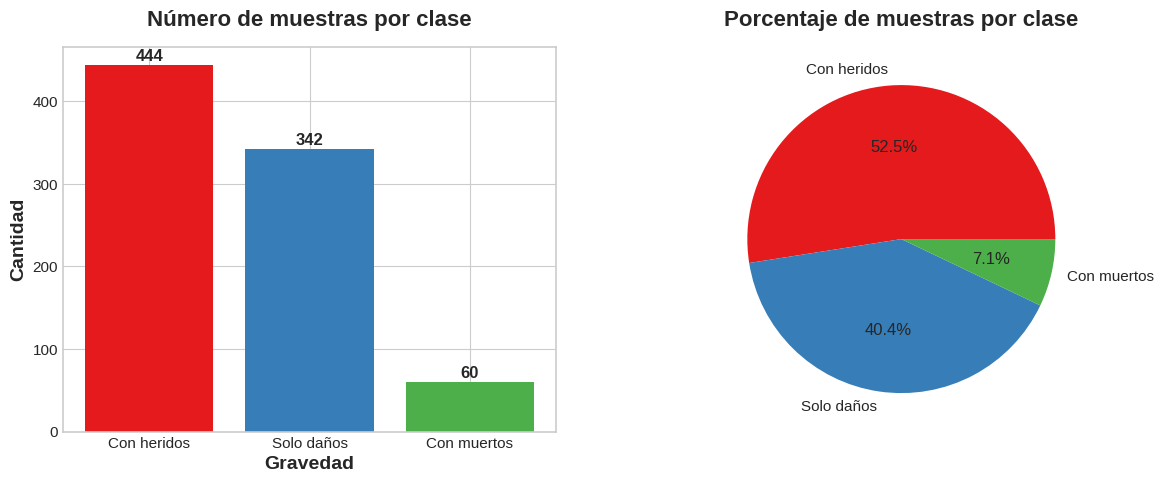

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de Barras
class_counts = df['gravedad'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('Set1', 3))
axes[0].set_title('Número de muestras por clase', fontweight='bold')
axes[0].set_xlabel('Gravedad')
axes[0].set_ylabel('Cantidad')

for bar in axes[0].patches:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width() / 2, height + 5, int(height), ha='center', fontweight='bold')

# Grafico de pastel
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set1', len(class_counts)))
axes[1].set_title('Porcentaje de muestras por clase', fontweight='bold')

*Desbalanceado*

#### **Gráfico de distribucción de features por gravedad**

In [34]:
feature_to_plot = [
    'numero_victima_peaton',
    'numero_victima_acompanante',
    'numero_victima_pasajero',
    'numero_victima_conductor'
]

In [35]:
target_col = 'gravedad'

In [36]:
dfg = df[feature_to_plot + [target_col]].groupby(target_col)
dfg.mean()

,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor
gravedad,,,,
Con heridos,0.117117,0.031532,0.175676,0.493243
Con muertos,0.100000,0.083333,1.050000,0.683333
Solo daños,0.000000,0.000000,0.000000,0.002924


In [37]:
dfg.size()

,0
gravedad,
Con heridos,444
Con muertos,60
Solo daños,342


In [38]:
accidents_class = df[target_col].unique()

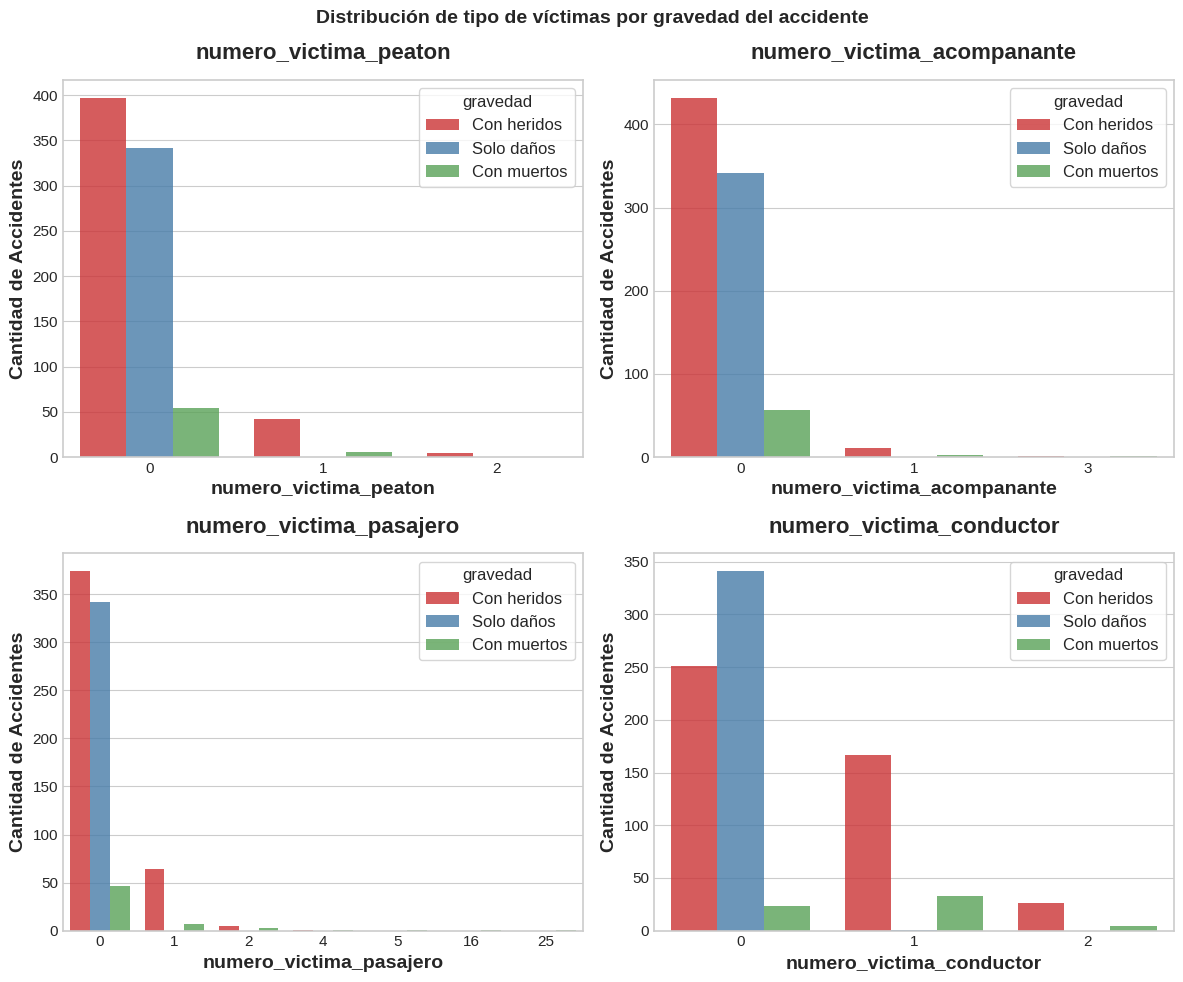

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(feature_to_plot):
    sns.countplot(data=df, x=feature, hue=target_col, ax=axes[i], alpha=0.8, palette="Set1")
    axes[i].set_title(feature, fontweight='bold')
    axes[i].set_ylabel('Cantidad de Accidentes')

plt.suptitle('Distribución de tipo de víctimas por gravedad del accidente', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### **Gráfico de barras Distribución de clase accidente**

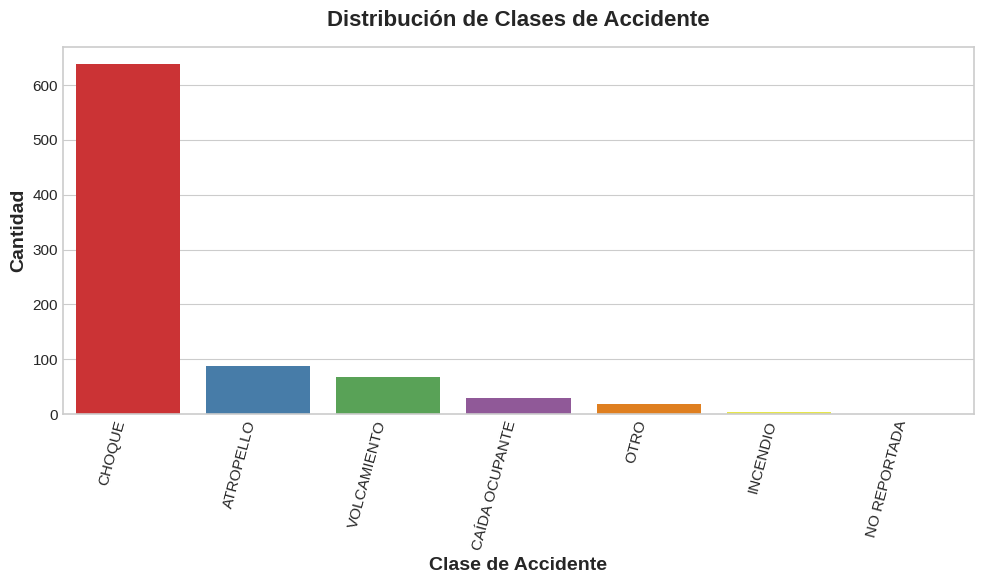

In [40]:
plt.figure(figsize=(10, 6))

# ordenar las barras de mayor a menor para mejor lectura
orden = df['clase_accidente'].value_counts().index
sns.countplot(data=df, x='clase_accidente', order=orden, palette='Set1')

plt.title('Distribución de Clases de Accidente', fontweight='bold')
plt.xlabel('Clase de Accidente')
plt.ylabel('Cantidad')

# Rotar las etiquetas del eje X para que no se superpongan
plt.xticks(rotation=75, ha='right')

# Asegura que nada se corte en los bordes
plt.tight_layout()
plt.show()

#### **Gráfico histogrma distribución de hora**



In [41]:
#Hora entera
df['hora_entera'] = df['hora_accidente'].astype(str).str.split(':').str[0]

# Convertimos a numérico, forzando errores a NaN, llenando con 0 y pasando a entero
df['hora_entera'] = pd.to_numeric(df['hora_entera'], errors='coerce').fillna(0).astype(int)


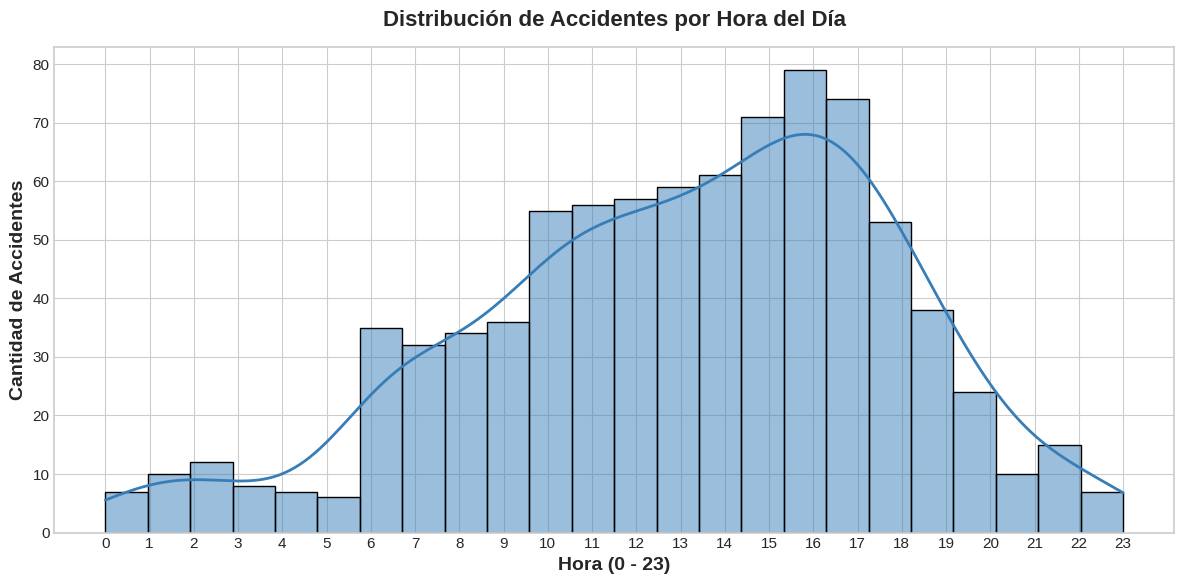

In [42]:
fig, axes = plt.subplots(1, 1, figsize=(12, 6))

# Usa histplot de Seaborn con la curva de densidad (KDE)
sns.histplot(data=df, x='hora_entera', bins=24, kde=True, color=sns.color_palette("Set1")[1], ax=axes)

axes.set_title('Distribución de Accidentes por Hora del Día', fontweight='bold')
axes.set_xlabel('Hora (0 - 23)', fontweight='bold')
axes.set_ylabel('Cantidad de Accidentes', fontweight='bold')

# el eje X muestra todas las horas del día de 0 a 23
axes.set_xticks(np.arange(0, 24, 1))

plt.tight_layout()
plt.show()

### **I. Matriz de correlación**

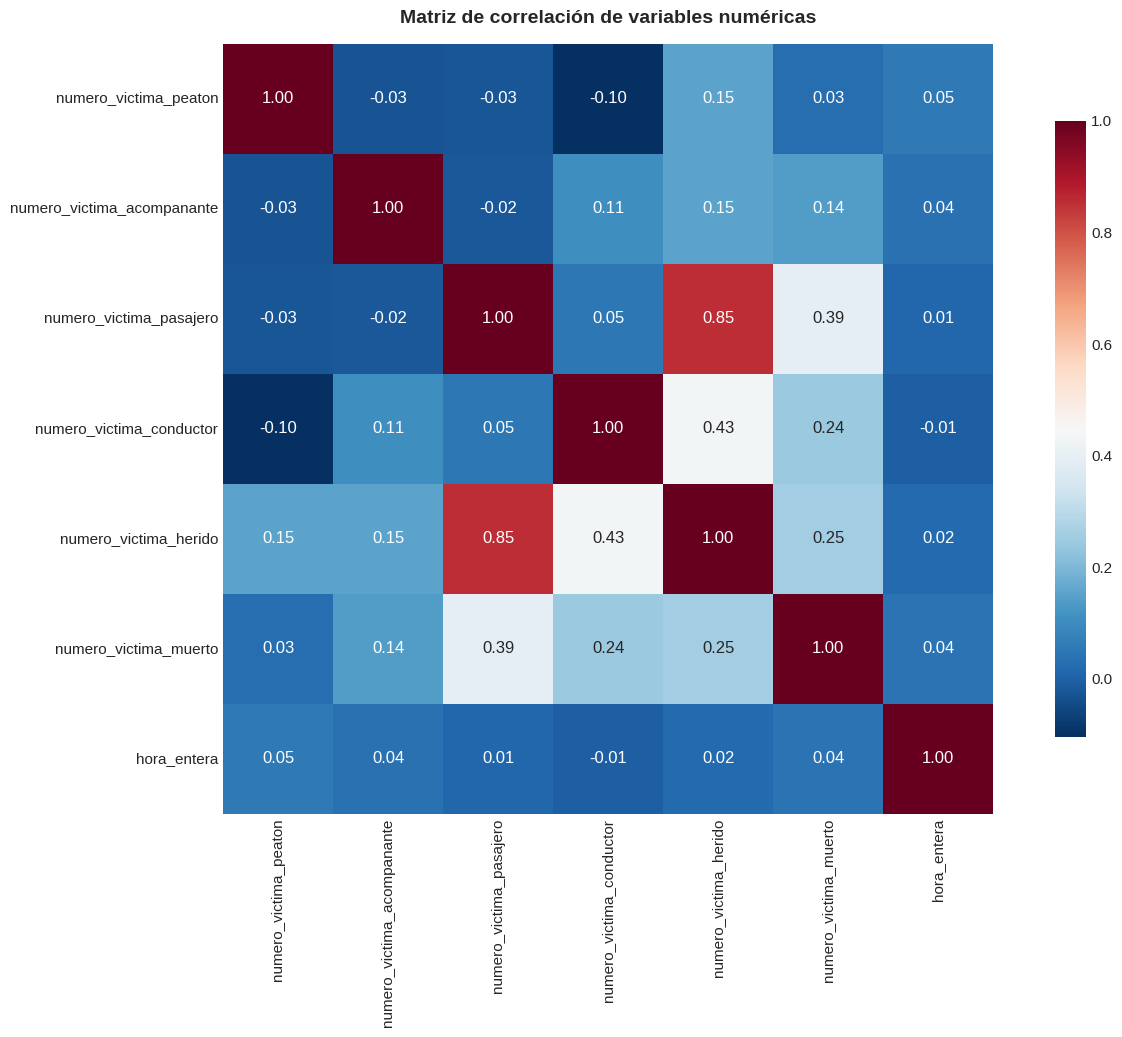

In [43]:
fig, ax = plt.subplots(figsize=(16, 10))

df_numerico = df.select_dtypes(include=['int64', 'float64'])
correlacion = df_numerico.corr()

sns.heatmap(correlacion,
            annot=True, fmt='.2f', cmap='RdBu_r', ax=ax, cbar_kws={'shrink': 0.8}, square=True)
ax.set_title('Matriz de correlación de variables numéricas', fontweight='bold', fontsize=14)

plt.show()

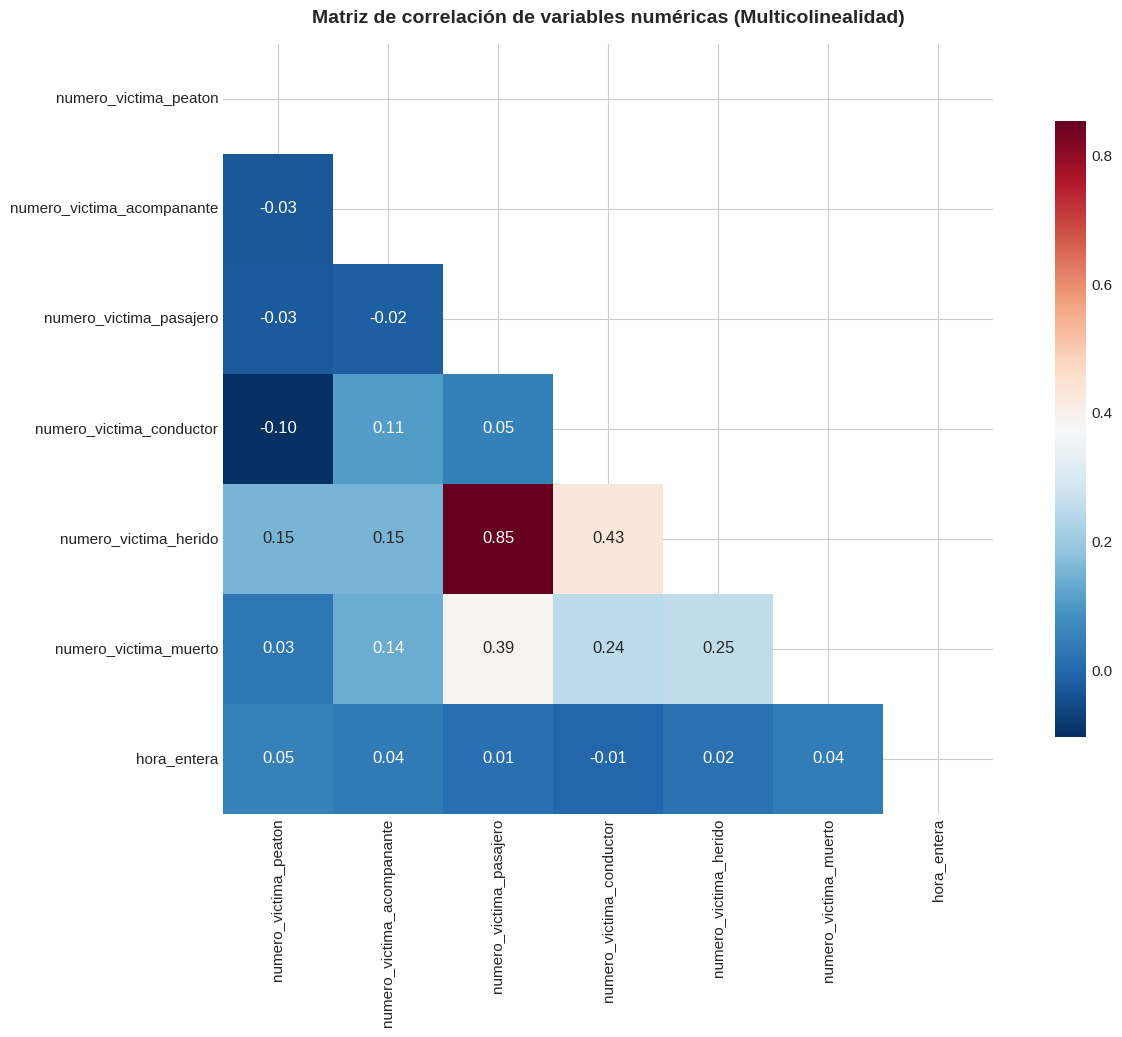

In [44]:
fig, ax = plt.subplots(figsize=(16, 10))

df_numerico = df.select_dtypes(include=['int64', 'float64'])
correlacion = df_numerico.corr()

mask = np.triu(np.ones_like(correlacion, dtype=bool))  #Simetria

sns.heatmap(correlacion,
            annot=True, mask=mask, fmt='.2f', cmap='RdBu_r', ax=ax, cbar_kws={'shrink': 0.8}, square=True)
ax.set_title('Matriz de correlación de variables numéricas (Multicolinealidad)', fontweight='bold', fontsize=14)

plt.show()

! Multicolinealidad (Menor a -80 o Mayor a 80) Puede generar redundacia en ciertos modelos

## **3. Preprocesamiento: Limpieza, calidad e ingeniería de carácteristicas**.


### **A. Estandarización de textos**

In [45]:
cl_texto = df.select_dtypes(include=['object']).columns

unicos_antes = df[cl_texto].nunique()

for col in cl_texto:
    df[col] = df[col].astype(str).str.lower().str.strip()

unicos_despues = df[cl_texto].nunique()

resumen = pd.DataFrame({
    'Únicos Antes': unicos_antes,
    'Únicos Después': unicos_despues
})

resumen['Reducción'] = resumen['Únicos Antes'] - resumen['Únicos Después']

print(resumen)

                          Únicos Antes  Únicos Después  Reducción
fecha_accidente                    649             649          0
hora_accidente                     214             214          0
gravedad                             3               3          0
clase_accidente                      7               7          0
causante_accidente                   2               2          0
descripcion_colisionante             5               4          1
descripcion_objeto_fijo              9               9          0
zona_accidente                       8               7          1
descripcion_de_estado                7               5          2
area_accidente                       5               3          2
sector_accidente                     8               4          4
descripcion_localizacion            13              13          0
estado_clima                         5               3          2
municipio                           35              35          0
direccion_

### **B. Eliminación de duplicados**

In [46]:
duplicados = df.duplicated().sum()
duplicados

np.int64(0)

In [47]:
if duplicados > 0:
    df = df.drop_duplicates().reset_index(drop=True)

### **C. Manejo de variables no reportadas**


Estandarizar textos a nulos reales (NaN) en todo el dataframe df

In [48]:
cols_txt = df.select_dtypes(include=['object']).columns
for c in cols_txt:
    df[c] = df[c].replace(['no reportado', 'no reporta'], np.nan)

#### Eliminar columnas  (> 70% de nulos)

In [49]:
umbral = 0.70
porcentaje_nulos = df.isna().mean()
porcentaje_nulos

,0
fecha_accidente,0.000000
hora_accidente,0.000000
gravedad,0.000000
clase_accidente,0.000000
causante_accidente,0.000000
descripcion_colisionante,0.245863
descripcion_objeto_fijo,0.920804
zona_accidente,0.983452
descripcion_de_estado,0.000000
area_accidente,0.001182


In [50]:
col_eliminar = porcentaje_nulos[porcentaje_nulos > umbral].index
col_eliminar

Index(['descripcion_objeto_fijo', 'zona_accidente'], dtype='object')

In [51]:
print(f"Columnas eliminadas por superar el 70% de nulos: {list(col_eliminar)}")
df_prep = df.drop(columns=col_eliminar)

Columnas eliminadas por superar el 70% de nulos: ['descripcion_objeto_fijo', 'zona_accidente']


#### Eliminar variables no predictivas

In [52]:
cols_nopred = ['direccion_lugar', 'fecha_accidente', 'hora_accidente']

df_prep = df_prep.drop(columns=cols_nopred, errors='ignore')
df_prep.head()

,gravedad,clase_accidente,causante_accidente,descripcion_colisionante,descripcion_de_estado,area_accidente,sector_accidente,descripcion_localizacion,estado_clima,municipio,numero_victima_peaton,numero_victima_acompanante,numero_victima_pasajero,numero_victima_conductor,numero_victima_herido,numero_victima_muerto,hora_entera
0,con heridos,choque,ciclista-motociclista,vehículo,fallado,rural,NaN,tramo de vía,normal,amaga,0,0,0,0,0,0,6
1,solo daños,choque,ciclista-motociclista,vehículo,fallado,urbana,residencial,tramo de vía,normal,amaga,0,0,0,0,0,0,11
2,con heridos,volcamiento,ciclista-motociclista,NaN,pend. notificación,urbana,comercial,tramo de vía,normal,NaN,0,0,0,0,0,0,12
3,solo daños,choque,ciclista-motociclista,vehículo,fallado,rural,NaN,tramo de vía,normal,NaN,0,0,0,0,0,0,9
4,con heridos,caída ocupante,ciclista-motociclista,NaN,fallado,rural,NaN,tramo de vía,normal,NaN,0,0,0,0,0,0,21


#### Reemplazar faltantes menores al 5% con el valor más frecuente

In [53]:
cols = ['clase_accidente', 'area_accidente', 'descripcion_localizacion']

# Configuramos el imputer para usar el valor más frecuente
imputador_moda = SimpleImputer(strategy='most_frequent')

# Aplicamos la imputación solo a esas tres columnas
df_prep[cols] = imputador_moda.fit_transform(df_prep[cols])

#### Imputar nulos en columnas moderadas/altas con una categoría nueva

In [54]:
cols_imputar = ['descripcion_colisionante', 'municipio', 'sector_accidente']
for c in cols_imputar:
    if c in df_prep.columns:
        df_prep[c] = df_prep[c].fillna('desconocido')
df_prep = df_prep.reset_index(drop=True)
print(df_prep.isna().sum())


gravedad                      0
clase_accidente               0
causante_accidente            0
descripcion_colisionante      0
descripcion_de_estado         0
area_accidente                0
sector_accidente              0
descripcion_localizacion      0
estado_clima                  0
municipio                     0
numero_victima_peaton         0
numero_victima_acompanante    0
numero_victima_pasajero       0
numero_victima_conductor      0
numero_victima_herido         0
numero_victima_muerto         0
hora_entera                   0
dtype: int64


### **D. Encoding**

#### **Label Encoding**

In [55]:
le = preprocessing.LabelEncoder()
le.fit(df_prep['gravedad'])

LabelEncoder()

In [56]:
print("Clases aprendidas por el LabelEncoder (le.classes_):")
print(le.classes_)

Clases aprendidas por el LabelEncoder (le.classes_):
['con heridos' 'con muertos' 'solo daños']


In [57]:
df_prep['gravedad'] = le.transform(df_prep['gravedad'])

print("Transformación de gravedad:")
print(df_prep['gravedad'])

Transformación de gravedad:
0      0
1      2
2      0
3      2
4      0
      ..
841    0
842    0
843    0
844    0
845    2
Name: gravedad, Length: 846, dtype: int64


### **E. Data Quality**



#### **Algortimos DataQuality**



##### Algortimo Quality Score (DQS)
Evalúa la salud de los datos post-encoding antes de modelar.
Inspirado en métricas de DAMA International (Data Management Association).

In [59]:
def calcular_dqs(df_eval):
    total_celdas = df_eval.size
    celdas_vacias = df_eval.isnull().sum().sum()

    # Completitud: Porcentaje de datos no faltantes (Peso: 50%)
    completitud = ((total_celdas - celdas_vacias) / total_celdas) * 100

    # Unicidad: Ausencia de duplicados exactos en filas (Peso: 25%)
    # Aplicable especialmente en la matriz ml post-encoding
    duplicados_pct = (df_eval.duplicated().sum() / len(df_eval)) * 100
    unicidad = 100 - duplicados_pct

    # Validez de Tipos: Todos los datos deben ser numéricos para ML (Peso: 25%)
    cols_numericas = df_eval.select_dtypes(include=[np.number, bool]).columns
    validez = (len(cols_numericas) / len(df_eval.columns)) * 100

    dqs_total = (completitud * 0.50) + (unicidad * 0.25) + (validez * 0.25)

    print("=" * 60)
    print(f"SCORE DE CALIDAD DE DATOS (DQS): {dqs_total:.2f}/100")
    print("-" * 60)
    print(f"- Completitud: {completitud:.2f}%")
    print(f"- Unicidad:    {unicidad:.2f}%")
    print(f"- Validez ML:  {validez:.2f}%")
    print("=" * 60)


# Evaluamos la variable df_ml que acabas de crear con pd.get_dummies
calcular_dqs(df_ml)

SCORE DE CALIDAD DE DATOS (DQS): 97.13/100
------------------------------------------------------------
- Completitud: 100.00%
- Unicidad:    88.53%
- Validez ML:  100.00%


##### Algortimo Detección de Anomalías (Método IQR)

In [60]:
def reporte_anomalias_iqr(df_eval):
    print("=" * 60)
    print("REPORTE DE ANOMALÍAS ESTADÍSTICAS (MÉTODO IQR)")
    print(f"{'Columna (Numérica)':<30} | {'Outliers':<10} | {'%'}")
    print("-" * 60)

    # Evaluamos solo las variables que no son booleanas (producto del encoding)
    # y que tienen un rango numérico continuo o discreto amplio.
    cols_continuas = [col for col in df_eval.columns if df_eval[col].nunique() > 5]
    total_anomalias = 0

    for col in cols_continuas:
        Q1 = df_eval[col].quantile(0.25)
        Q3 = df_eval[col].quantile(0.75)
        IQR = Q3 - Q1

        limite_inf = Q1 - 1.5 * IQR
        limite_sup = Q3 + 1.5 * IQR

        outliers = ((df_eval[col] < limite_inf) | (df_eval[col] > limite_sup)).sum()
        pct_outliers = (outliers / len(df_eval)) * 100
        total_anomalias += outliers

        if outliers > 0:
            print(f"{col:<30} | {outliers:<10} | {pct_outliers:.1f}%")

    print("=" * 60)
    print(f"Total registros con posibles anomalías detectadas: {total_anomalias}")


# Evaluamos df_ml
reporte_anomalias_iqr(df_ml)

REPORTE DE ANOMALÍAS ESTADÍSTICAS (MÉTODO IQR)
Columna (Numérica)             | Outliers   | %
------------------------------------------------------------
numero_victima_pasajero        | 84         | 9.9%
numero_victima_herido          | 16         | 1.9%
Total registros con posibles anomalías detectadas: 100


##### Algortimo Data Profiling / Dispersión post-Encoding

In [61]:
def perfilamiento_ml(df_eval):
    # Detectar columnas con Varianza Cero (Variables constantes)
    # Una variable con un solo valor no aporta información al modelo predictivo.
    varianza_cero = [col for col in df_eval.columns if df_eval[col].nunique() == 1]

    # Detectar alta dispersión en variables creadas por One-Hot Encoding
    # Si una columna categórica codificada (0 y 1) tiene menos del 1% de 1s,
    # significa que es un evento demasiado raro y puede causar sobreajuste (overfitting).
    columnas_raras = []
    for col in df_eval.columns:
        if set(df_eval[col].unique()).issubset({0, 1, False, True}):
            pct_positivos = (df_eval[col].sum() / len(df_eval)) * 100
            if pct_positivos < 1.0:
                columnas_raras.append((col, pct_positivos))

    print("=" * 60)
    print("DATA PROFILING POST-ENCODING")
    print("-" * 60)
    print(f"Total variables para ML: {len(df_eval.columns)}")
    print(f"Variables con Varianza Cero (Inútiles): {len(varianza_cero)}")
    if varianza_cero: print(f"-> {varianza_cero}")

    print(f"\nVariables (Dummies) con muy baja frecuencia (< 1%): {len(columnas_raras)}")
    if columnas_raras:
        # Mostrar solo las primeras 5 para no saturar la pantalla
        for col, pct in columnas_raras[:5]:
            print(f"-> {col}: {pct:.2f}%")
        if len(columnas_raras) > 5:
            print(f"-> ... y {len(columnas_raras) - 5} más.")
    print("=" * 60)


# Evaluamos df_ml
perfilamiento_ml(df_ml)

DATA PROFILING POST-ENCODING
------------------------------------------------------------
Total variables para ML: 73
Variables con Varianza Cero (Inútiles): 0

Variables (Dummies) con muy baja frecuencia (< 1%): 35
-> clase_accidente_incendio: 0.35%
-> clase_accidente_no reportada: 0.12%
-> causante_accidente_conductor: 0.35%
-> descripcion_de_estado_pend. fallo: 0.35%
-> descripcion_localizacion_interseccion: 0.24%
-> ... y 30 más.


### **F. Entrenamiento**

#### **Separar variables independientes de las dependientes**

In [62]:
X = df_ml.drop('gravedad', axis=1)
y = df_ml['gravedad']
#Sacamos el 5% para Validación
X_train_temp, X_val, y_train_temp, y_val = train_test_split(
    X,
    y,
    test_size=0.05,
    random_state=3,
    stratify=y
)
#Del 95% restante, sacamos el 15% para Prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.15,
    random_state=3,
    stratify=y_train_temp
)

print("Distribución Original:", np.unique(y, return_counts=True))
print("Distribución Entrenamiento:", np.unique(y_train, return_counts=True))
print("Distribución Validación:", np.unique(y_val, return_counts=True))
print("Distribución Prueba:", np.unique(y_test, return_counts=True))

Distribución Original: (array([0, 1, 2]), array([444,  60, 342]))
Distribución Entrenamiento: (array([0, 1, 2]), array([358,  48, 276]))
Distribución Validación: (array([0, 1, 2]), array([23,  3, 17]))
Distribución Prueba: (array([0, 1, 2]), array([63,  9, 49]))


#### **Estandarización de variables numéricas**


In [63]:
scaler = StandardScaler()

# fit_transform: Aprende la media/desviación de Train y los escala
X_train_scaled = scaler.fit_transform(X_train)

# transform: Usa lo aprendido en Train para escalar Test
X_test_scaled = scaler.transform(X_test)

print("Datos escalados con standard scaler")
print(f'Media: {X_train_scaled.mean():.6f}')  #si está bien tiende a 0
print(f'Desviación estándar: {X_train_scaled.std():.6f}')  #tiende a 1


Datos escalados con standard scaler
Media: -0.000000
Desviación estándar: 0.993031


#### **Evaluación del modelos**

In [64]:
modelos = {
    'Logistic Regresion': LogisticRegression(max_iter=1000, random_state=5),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=5),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=5),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=3, random_state=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, subsample=0.8,
                                                    random_state=5),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, learning_rate=0.1, random_state=5),
    'MLP Red Neuronal': MLPClassifier(hidden_layer_sizes=(16,), alpha=0.01, max_iter=1000, random_state=5),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, max_depth=5, min_samples_leaf=3, random_state=5),
    'Bagging': BaggingClassifier(random_state=5),
    'SGD': SGDClassifier(random_state=5),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
    'HistGradient Boosting': HistGradientBoostingClassifier(random_state=5),
    'Gaussian Process': GaussianProcessClassifier(1.0 * RBF(1.0), random_state=5),
    'Ridge Classifier': RidgeClassifier(random_state=5),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=5),
    'DummyClassifier': DummyClassifier(strategy='most_frequent')
}


In [65]:
print(f' Cantidad de modelos: {len(modelos)}')

 Cantidad de modelos: 19


In [66]:
resultados = []
resultados

[]

In [67]:
print('*' * 85)
print(f'{"Modelo":<25} {"CV Mean":<15} {"CV Std":<15} {"Test accuracy":<15} {"F1 Macro":<15}')
print('*' * 85)

for nombre, modelo in modelos.items():
    cv_scores = cross_val_score(modelo, X_train_scaled, y_train, cv=5, scoring='accuracy')
    modelo.fit(X_train_scaled, y_train)
    y_pred = modelo.predict(X_test_scaled)
    test_accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    resultados.append({
        'Modelo': nombre,
        'CV_Mean': cv_scores.mean(),
        'CV_STD': cv_scores.std(),
        'Test Accuracy': test_accuracy,
        'F1 Macro': f1
    })

    cv_str = f"{cv_scores.mean():.4f} +- {cv_scores.std():.4f}"
    print(f'{nombre:<25} {cv_scores.mean():<15.4f} {cv_scores.std():<15.4f} {test_accuracy:<15.4f} {f1:<15.4f}')
print('*' * 85)

*************************************************************************************
Modelo                    CV Mean         CV Std          Test accuracy   F1 Macro       
*************************************************************************************
Logistic Regresion        0.8592          0.0260          0.8347          0.8296         
SVM                       0.8021          0.0279          0.7934          0.7945         
KNN                       0.7141          0.0287          0.7521          0.7098         
Decision Tree             0.8359          0.0302          0.8430          0.8508         
Naive Bayes               0.1950          0.0118          0.1653          0.1704         
Random Forest             0.8344          0.0242          0.8347          0.8238         
Gradient Boosting         0.8520          0.0346          0.8678          0.8688         
AdaBoost                  0.7948          0.0268          0.8017          0.8225         
MLP Red Neuronal  

In [68]:
df_resultados = pd.DataFrame(resultados).sort_values(by='Test Accuracy', ascending=False)
df_resultados = df_resultados.reset_index(drop=True)
print("Ranking de los modelos por Test accuracy")
df_resultados

Ranking de los modelos por Test accuracy


,Modelo,CV_Mean,CV_STD,Test Accuracy,F1 Macro
0,HistGradient Boosting,0.821189,0.028676,0.876033,0.860045
1,Gradient Boosting,0.851964,0.034597,0.867769,0.868800
2,Bagging,0.832890,0.027217,0.859504,0.862245
3,MLP Red Neuronal,0.838751,0.019344,0.859504,0.836249
4,Ridge Classifier,0.813793,0.028004,0.851240,0.857285
5,LDA,0.818205,0.038603,0.842975,0.851524
6,Gaussian Process,0.853403,0.016449,0.842975,0.850714
7,Decision Tree,0.835852,0.030183,0.842975,0.850774
8,SGD,0.828446,0.007469,0.834711,0.845050
9,Logistic Regresion,0.859242,0.026027,0.834711,0.829584


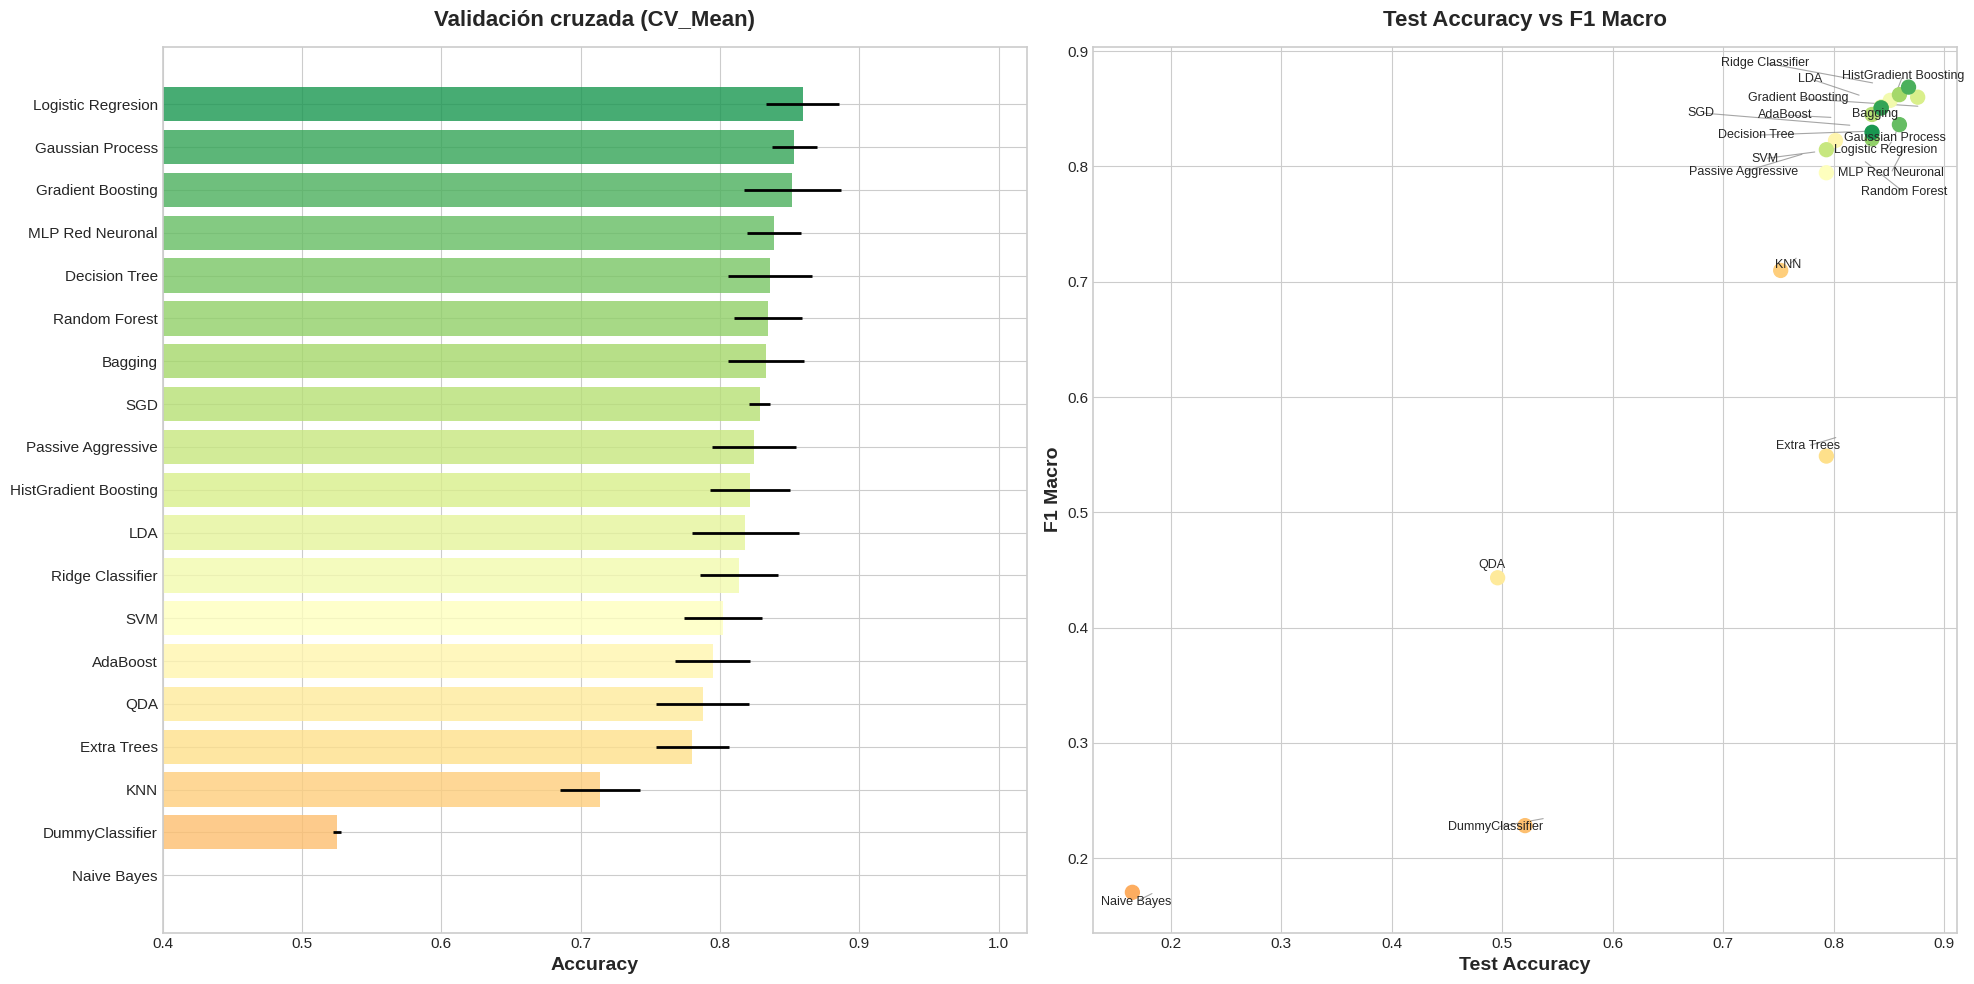

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

df_plot = df_resultados.sort_values('CV_Mean')
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(df_plot)))

ax[0].barh(df_plot['Modelo'], df_plot['CV_Mean'], xerr=df_plot['CV_STD'], color=colors, alpha=0.8)
ax[0].set_xlabel('Accuracy', fontweight='bold')
ax[0].set_title('Validación cruzada (CV_Mean)', fontweight='bold')
ax[0].set_xlim(0.40, 1.02)

ax[1].scatter(df_plot['Test Accuracy'], df_plot['F1 Macro'], color=colors, s=100, zorder=5)

texts = []
num_points = len(df_plot)

for i, (_, row) in enumerate(df_plot.iterrows()):
    x_val = row['Test Accuracy']
    y_val = row['F1 Macro']

    angle = (i / num_points) * 2 * np.pi

    radio_x = 0.02
    radio_y = 0.02

    x_start = x_val + (np.cos(angle) * radio_x)
    y_start = y_val + (np.sin(angle) * radio_y)

    t = ax[1].text(x_start, y_start, row['Modelo'],
                   fontsize=9, ha='center', va='center', zorder=10)
    texts.append(t)
adjust_text(texts, ax=ax[1],
            arrowprops=dict(arrowstyle="-", color='gray', lw=0.8, alpha=0.7),
            expand_points=(1.5, 1.5))

ax[1].set_xlabel('Test Accuracy', fontweight='bold')
ax[1].set_ylabel('F1 Macro', fontweight='bold')
ax[1].set_title('Test Accuracy vs F1 Macro', fontweight='bold')

plt.tight_layout()
plt.show()

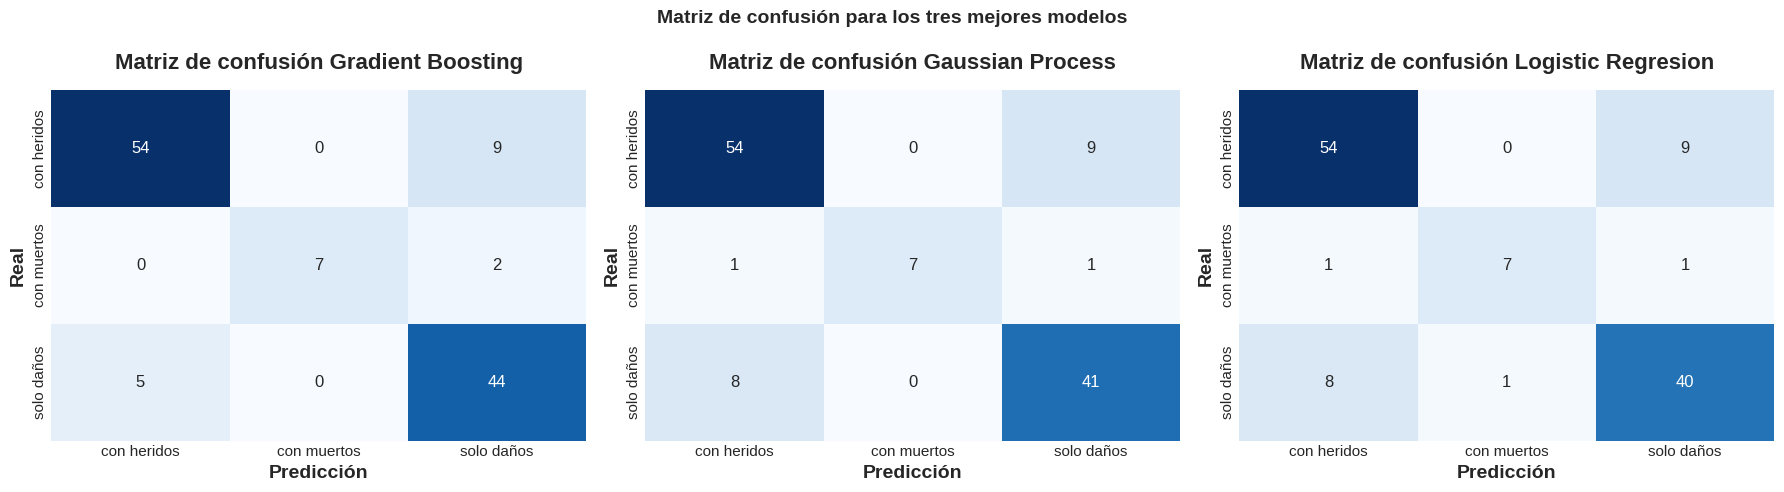

In [70]:
top_3 = df_resultados.sort_values('CV_Mean').tail(3)['Modelo'].tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, nombre in zip(axes, top_3):
    modelo = modelos[nombre]
    y_pred = modelo.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=le.classes_, yticklabels=le.classes_,
                cbar=False)

    ax.set_title(f'Matriz de confusión {nombre}', fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predicción')
plt.suptitle('Matriz de confusión para los tres mejores modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()